In [1]:
import pandas as pd
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import string
import re

---
# Data Overview

In [2]:
df = pd.read_csv(
    '../data/spam.csv',
    encoding='latin-1',
)

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [5]:
df.describe().transpose()

,count,unique,top,freq
v1,5572,2,ham,4825
v2,5572,5169,"Sorry, I'll call later",30
Unnamed: 2,50,43,"bt not his girlfrnd... G o o d n i g h t . . .@""",3
Unnamed: 3,12,10,"MK17 92H. 450Ppw 16""",2
Unnamed: 4,6,5,"GNT:-)""",2


---
# Data Cleaning and Preparation

**When we loaded the dataset, we saw that our dataframe has 5 features, but considering that the dataset description states that According to the dataset description, the meaningful columns are v1 (label) and v2 (message text), and according to the describe, it is clear that the Unnamed: 2 feature only has 50 values, the Unnamed: 3 feature only has 12 values, and the Unnamed: 4 feature only has 6 values. As a result, these features are not very important and we remove them.**

In [6]:
df.drop(
    labels=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],
    axis=1,
    inplace=True
)

In [7]:
df.columns = ['label', 'text']

In [8]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**The dataset contains duplicate messages. Since duplicate samples can cause bias during model training and evaluation, duplicate rows were removed.**

In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [11]:
df['text'] = df['text'].apply(clean_text)

In [12]:
df.duplicated().sum()

np.int64(416)

In [13]:
df.drop_duplicates(inplace=True)

---
# Missing Values

In [14]:
df.isnull().sum()

label    0
text     0
dtype: int64

**This dataset has no missing data.**

---
# Save DataFrame Processed
**The processed dataframe is saved for the training phase. 
The additional features created later (text length, word count, special character count) are only used for EDA analysis and are not included in the final model because TF-IDF is used for feature extraction.**

In [15]:
df.to_csv('../data/spam_processed.csv', index=False)

---
# Data Analysis

In [16]:
df['label'].value_counts()

label
ham     4515
spam     641
Name: count, dtype: int64

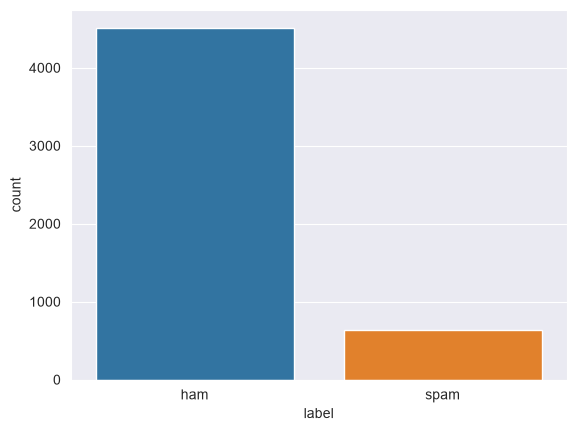

In [17]:
sns.countplot(data=df, x='label', hue='label');

**The target is severely unbalanced, so we should not use the accuracy criterion alone to evaluate the model, and the best option is to use the F1-Score criterion.**

In [18]:
df['text_length'] = df['text'].apply(len)

In [19]:
df.groupby('label')['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4515.0,70.337763,56.230990,2.0,34.0,52.0,90.0,910.0
spam,641.0,134.747270,30.936251,13.0,125.0,145.0,156.0,224.0


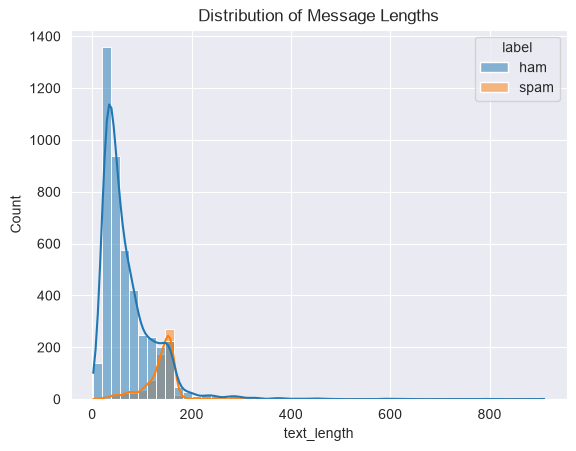

In [20]:
sns.histplot(data=df, x='text_length', hue='label', kde=True, bins=50)
plt.title('Distribution of Message Lengths');

**Based on the result of describe on the new text_length group, we see that most spam messages are usually longer.**

In [21]:
df['word_count'] = df['text'].apply(
    lambda x: len(x.split())
)

In [22]:
df.groupby('label')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4515.0,14.136213,11.116546,1.0,7.0,11.0,18.0,171.0
spam,641.0,23.503900,6.055762,2.0,21.0,25.0,28.0,35.0


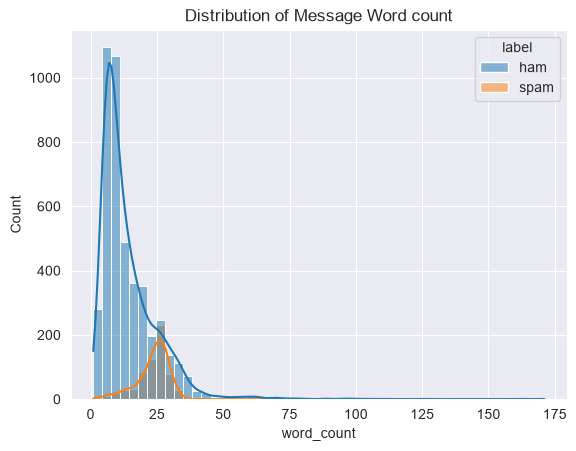

In [23]:
sns.histplot(data=df, x='word_count', hue='label', kde=True, bins=50)
plt.title('Distribution of Message Word count');

**Based on the result of describe on the new word_count group, we see that most spam messages tend to have a higher word count.**

In [24]:
df['text_special_char_count'] = df['text'].apply(
    lambda text: sum(char in string.punctuation for char in text)
)

In [25]:
df.groupby('label')['text_special_char_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4515.0,3.865559,4.521239,0.0,1.0,3.0,5.0,133.0
spam,641.0,5.157566,3.314524,0.0,3.0,5.0,7.0,26.0


**Based on the describe result on the new text_special_char_count group, we see that most spam messages tend to have a higher special character count.**

In [26]:
def top_30_frequent_words(label: str) -> (Counter, str):
    text = " ".join(
        df[(df['label']==label)]['text']
    )
    
    filtered_words = [
        word for word in text.split() if word not in STOPWORDS
    ]
    counter_words = Counter(filtered_words).most_common(30)
    
    return counter_words, text

In [27]:
def generate_wordcloud(text: str) -> WordCloud:
    wordcloud = WordCloud(
        width=1000,
        height=700,
        stopwords=STOPWORDS,
        include_numbers=True,
        collocations=False,
        regexp= r'\S+'
    ).generate(text)

    return wordcloud

In [28]:
counter_spam_word, spam_text = top_30_frequent_words('spam')

In [29]:
print(f'Top 30 Spam Words\n{counter_spam_word}')

Top 30 Spam Words
[('call', 289), ('free', 154), ('2', 150), ('ur', 119), ('txt', 112), ('text', 96), ('u', 96), ('reply', 93), ('mobile', 91), ('claim', 88), ('&', 88), ('stop', 83), ('now', 79), ('4', 74), ('new', 64), ('send', 54), ('now!', 52), ('prize', 51), ('won', 51), ('nokia', 50), ('-', 49), ('contact', 49), ('please', 46), ('cash', 46), ('win', 44), ('service', 42), ('will', 39), ('urgent!', 38), ('per', 37), ('customer', 32)]


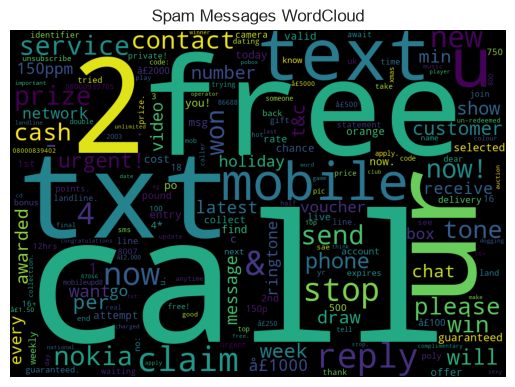

In [30]:
spam_wordcloud = generate_wordcloud(spam_text)
plt.imshow(spam_wordcloud)
plt.title("Spam Messages WordCloud")
plt.axis('off');

In [31]:
counter_ham_word, ham_text = top_30_frequent_words('ham')

In [32]:
print(f'Top 30 Spam Words\n{counter_ham_word}')

Top 30 Spam Words
[('u', 794), ('will', 305), ('2', 272), ('&lt;#&gt;', 254), ('go', 227), ('got', 221), ('come', 199), ('know', 197), ('ur', 195), ('?', 178), ('good', 171), ('call', 169), ('...', 159), ('.', 158), ('going', 152), ('4', 151), ('now', 150), ('want', 149), ('ok', 146), ('time', 145), ('need', 143), ('love', 139), ('still', 139), ('one', 134), ('think', 122), ('see', 122), ('n', 118), ('dont', 115), ('tell', 114), ('take', 107)]


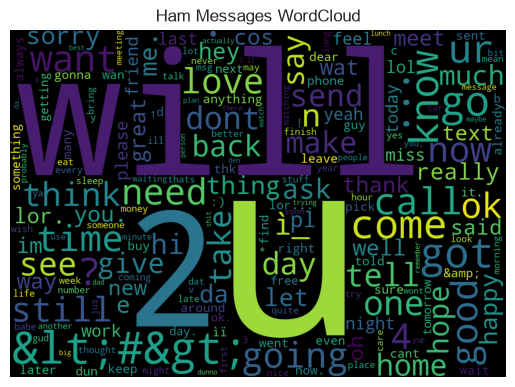

In [33]:
ham_wordcloud = generate_wordcloud(ham_text)
plt.imshow(ham_wordcloud)
plt.title("Ham Messages WordCloud")
plt.axis('off');